In [1]:
# Importation des bibliothèques
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from ucimlrepo import fetch_ucirepo 

In [2]:
csv_path = "../PhiUSIIL_Phishing_URL_Dataset.csv"
try:
    df = pd.read_csv(csv_path)
    print("Dataset chargé avec succès !")
except Exception as e:
    print(f"Erreur lors du chargement du dataset : {e}")

print(df.columns)


# Sélection des caractéristiques souhaitées
features_to_use = [
    'URLLength', 'DomainLength', 'NoOfSubDomain', 'IsDomainIP',
    'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfEqualsInURL',
    'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
    'SpacialCharRatioInURL', 'TLDLength'
]

# On crée le DataFrame final avec les caractéristiques (X) et la cible (y)
X = df[features_to_use]
Y = df['label']

print("\nCaractéristiques sélectionnées :")
print(X.head())
print(Y.head())
print(f"\nNombre d'échantillons: {len(df)}")

Dataset chargé avec succès !
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',

In [3]:
# Initialisation du normalisateur
scaler = MinMaxScaler()

# Normalisation des caractéristiques
X_scaled = scaler.fit_transform(X)

# Affichage des 5 premières lignes normalisées pour vérifier
print("Données après normalisation (5 premières lignes) :")
print(X_scaled[:5])

Données après normalisation (5 premières lignes) :
[[0.00295858 0.18867925 0.1        0.         0.00346754 0.
  0.         0.         0.         0.00200401 0.08060453 0.09090909]
 [0.00164366 0.11320755 0.1        0.         0.00173377 0.
  0.         0.         0.         0.00400802 0.21914358 0.        ]
 [0.00262985 0.16981132 0.2        0.         0.00288962 0.
  0.         0.         0.         0.00400802 0.17380353 0.        ]
 [0.00213675 0.14150943 0.1        0.         0.00250433 0.
  0.         0.         0.         0.00200401 0.09571788 0.09090909]
 [0.00328731 0.20754717 0.1        0.         0.00385282 0.
  0.         0.         0.         0.00200401 0.07556675 0.09090909]]


In [13]:
# Division des données en 80% pour l'entraînement et 20% pour la validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X_scaled, 
    Y, 
    test_size=0.2, 
    random_state=42, # Pour la reproductibilité des résultats
    stratify=Y # Assure que la proportion de labels est la même dans les deux ensembles
)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de validation : {X_val.shape[0]} échantillons")

Taille de l'ensemble d'entraînement : 188636 échantillons
Taille de l'ensemble de validation : 47159 échantillons


In [14]:
# Définition du modèle séquentiel
model = Sequential()

# Nombre de caractéristiques en entrée
input_dim = X_train.shape[1]

# 1. Couche d'entrée et première couche cachée
#    - Dense signifie que chaque neurone est connecté à tous ceux de la couche précédente.
#    - 'relu' (Rectified Linear Unit) est une fonction d'activation très courante.
model.add(Dense(128, input_dim=input_dim, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5)) # Ajout du dropout pour la régularisation

# 2. Deuxième couche cachée
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

# 3. Troisième couche cachée
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

# 4. Couche de sortie
#    - 1 neurone car c'est une classification binaire (phishing ou non).
#    - 'sigmoid' est la fonction d'activation idéale pour la sortie binaire, 
#      elle renvoie une probabilité entre 0 et 1.
model.add(Dense(1, activation='sigmoid'))


# Affichage d'un résumé de l'architecture du modèle
model.summary()

c:\Users\Aymeric\miniconda3\envs\DAML\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compilation du modèle
model.compile(
    optimizer='adam', # L'optimiseur Adam, très efficace et recommandé par défaut
    loss='binary_crossentropy', # La fonction de coût pour la classification binaire
    metrics=['accuracy'] # La métrique que l'on veut suivre pendant l'entraînement
)

print("\nLe modèle est maintenant construit et compilé, prêt pour l'entraînement !")


Le modèle est maintenant construit et compilé, prêt pour l'entraînement !


In [22]:
# Importer le callback
from tensorflow.keras.callbacks import EarlyStopping

# Configurer le callback pour surveiller la perte de validation
# 'patience=5' signifie qu'on attend 5 époques après la dernière amélioration avant d'arrêter.
early_stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Définition des paramètres d'entraînement
EPOCHS = 50  # Nombre de fois que le modèle verra l'ensemble des données
BATCH_SIZE = 64 # Nombre d'échantillons traités avant de mettre à jour les poids

print("Début de l'entraînement...")

# Lancer l'entraînement avec le callback
# Vous pouvez augmenter le nombre d'époques (ex: 100), 'early_stopper' s'arrêtera au bon moment.
history = model.fit(
    X_train,
    Y_train,
    epochs=50, # Mettez un nombre élevé
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    #callbacks=[early_stopper], # <--- AJOUT IMPORTANT
    verbose=1
)

print("\nEntraînement terminé !")

Début de l'entraînement...
Epoch 1/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8316 - loss: 0.4219 - val_accuracy: 0.8363 - val_loss: 0.4055
Epoch 2/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8320 - loss: 0.4229 - val_accuracy: 0.8295 - val_loss: 0.4177
Epoch 3/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8314 - loss: 0.4226 - val_accuracy: 0.8398 - val_loss: 0.4054
Epoch 4/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8316 - loss: 0.4228 - val_accuracy: 0.8353 - val_loss: 0.4022
Epoch 5/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8321 - loss: 0.4225 - val_accuracy: 0.8345 - val_loss: 0.4040
Epoch 6/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8316 - loss: 0.4227 - val_accuracy: 0.8363 - val_loss: 0.4087
Epoch 7/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8323 - loss: 0.4217 - val_accuracy: 0.8363 - val_loss: 0.4048
Epoch 8/50
2948/2948 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accurac

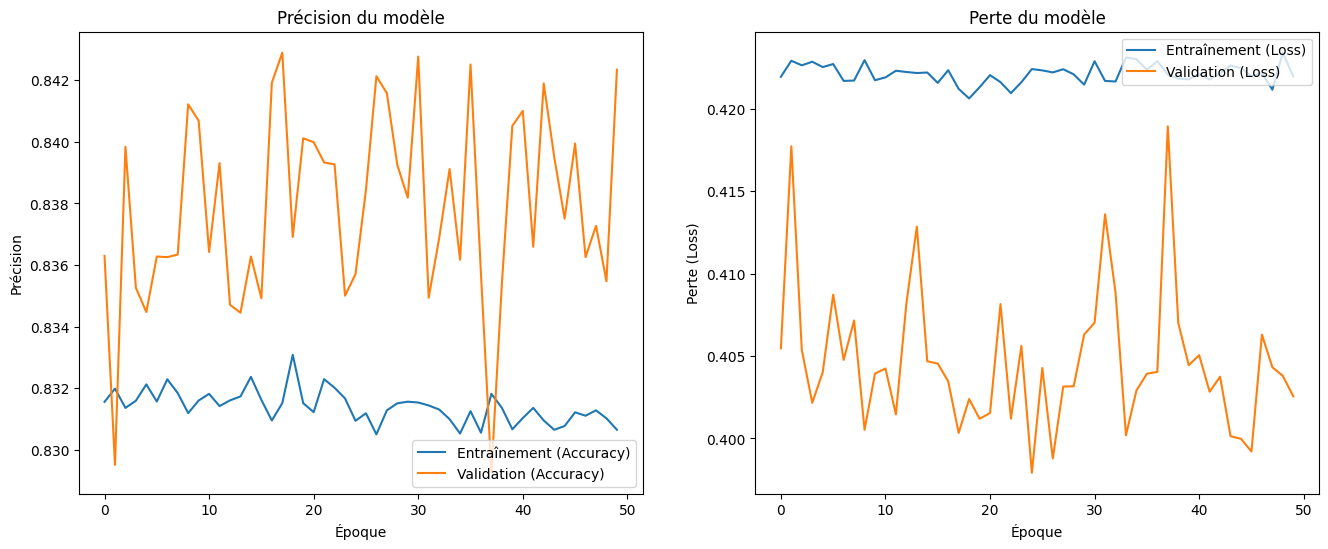

In [23]:
import matplotlib.pyplot as plt

# Fonction pour afficher les courbes de perte et de précision
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Courbe de précision
    ax1.plot(history.history['accuracy'], label='Entraînement (Accuracy)')
    ax1.plot(history.history['val_accuracy'], label='Validation (Accuracy)')
    ax1.set_title('Précision du modèle')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Précision')
    ax1.legend(loc='lower right')
    
    # Courbe de perte
    ax2.plot(history.history['loss'], label='Entraînement (Loss)')
    ax2.plot(history.history['val_loss'], label='Validation (Loss)')
    ax2.set_title('Perte du modèle')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Perte (Loss)')
    ax2.legend(loc='upper right')
    
    plt.show()

# Affichage des graphiques
plot_history(history)

--- Évaluation finale sur l'ensemble de validation ---
Perte (Loss)     : 0.4026
Précision (Accuracy) : 84.23%

1474/1474 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--- Rapport de Classification ---
              precision    recall  f1-score   support

Légitime (0)       0.93      0.68      0.79     20189
Phishing (1)       0.80      0.96      0.87     26970

    accuracy                           0.84     47159
   macro avg       0.87      0.82      0.83     47159
weighted avg       0.86      0.84      0.84     47159

--- Matrice de Confusion ---


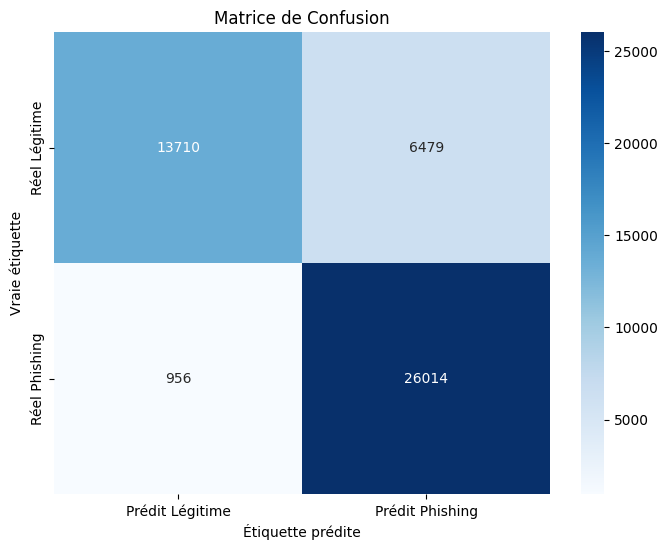

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# 1. Évaluation simple (Perte et Précision)
loss, accuracy = model.evaluate(X_val, Y_val, verbose=0)
print(f"--- Évaluation finale sur l'ensemble de validation ---")
print(f"Perte (Loss)     : {loss:.4f}")
print(f"Précision (Accuracy) : {accuracy * 100:.2f}%\n")


# 2. Prédictions pour obtenir des métriques détaillées
y_pred_probs = model.predict(X_val)
# Convertir les probabilités (ex: 0.98) en classes binaires (1)
y_pred_classes = (y_pred_probs > 0.5).astype(int)


# 3. Rapport de classification (Précision, Rappel, F1-Score)
print("--- Rapport de Classification ---")
# '1' = Phishing, '0' = Légitime
target_names = ['Légitime (0)', 'Phishing (1)'] 
print(classification_report(Y_val, y_pred_classes, target_names=target_names))


# 4. Matrice de Confusion
print("--- Matrice de Confusion ---")
cm = confusion_matrix(Y_val, y_pred_classes)

# Affichage avec Seaborn pour une meilleure lisibilité
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Légitime', 'Prédit Phishing'], 
            yticklabels=['Réel Légitime', 'Réel Phishing'])
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.show()